Demostration of the FEM-SIM module following the example 9.1 from 
'Polymer Processing. Modeling and Simulation - Tim A. Osswald and
Juan P. Hernandez

Dimension = 1
Physics = Steady state Heat Conduction

∇.(k∇T) + Q_viscous_heating = 0

Q_viscous_heating = n(du_y/dx)^2 ~ 25000 W/m3

h = 0.04m, n = 1000 Pa-s, k= 0.2 J/m/K, u0 = 0.2 m/s, Tm = 200°C

----------- Analytical solution ----------------
T(x) = Tm + (n/2k)*(u0/h)^2 * (2hx-x^2)


In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurar la ruta para importar 'Source'
# Agregamos la carpeta raíz al path de Python
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# 2. Activar Autoreload (Vital para desarrollo)
%load_ext autoreload
%autoreload 2

# 3. Importar tus clases de FEM
from Source.Pre_processing.Mesh import Mesh
from Source.core import Model
from Source.Material import material
from Source.Physics.HeatTransfer import ht

from Source.enums import ElementType, ShapeFunctionType, StudyType, ProblemType, SolverType

print("Entorno FEM-Sim cargado correctamente.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Entorno FEM-Sim cargado correctamente.


In [3]:
# Defining problem dimension: 1D
PD = 1 

# Create mesh from linear element

L = 0.04  # Length size of the domain [m]
NoE = 5  # Number of Elements
MeshType = ElementType.line  # Type of element
shapeFunction = ShapeFunctionType.linear  # Shape function for spatial discretization

In [4]:
Mesh1 = Mesh()
Mesh1.Generate_Mesh(PD, L, NoE, MeshType)
Mesh1.setElementShapeFunction(shapeFunction)

Mesh1.defineBoundary('inlet', 0)
Mesh1.defineBoundary('outlet', NoE) # Hardcoded

Mesh1.checkBoundaries()

[0, 5]


[0, 5]

In [5]:
# Defining material properties
Mat1 = material('Polymer', k = 0.2, miu=1.0, rho=1.0, Cp= 1.0)

In [6]:
# Defining main model
Model1 = Model(name='Couette_device', mtype=None, dim=PD, mesh=Mesh1, mat=Mat1, psc=ht)

# Adding source term (Q_viscous_heating)
Model1.physics.source = 25000.0

# Neglecting convection term
Model1.physics.Convection = False
Model1.physics.Stab = None

# Adding boundary conditions
Model1.physics.addBC_Temperature(id=0, T=200.0)
Model1.physics.addBC_HeatFlux(id=Mesh1.boundaries['outlet'], q_flux = 0.0)


# Initialize field
Model1.physics.initField('T', 200.0)

In [7]:
# Initialize field
Model1.physics.initField('T', 200.0)

# Setting solver options

solverOptions = {'Study': StudyType.steady_state, 'Type': ProblemType.linear, 'Method': SolverType.direct, 'Solver':'PARDISO'}

Model1.solverConfiguration(**solverOptions)

In [8]:
# Solving PDE
Model1.solve()

-------Simulation started-------
method finished on 1.082 seconds
Simulation finished


Text(0, 0.5, 'Temperature [°C]')

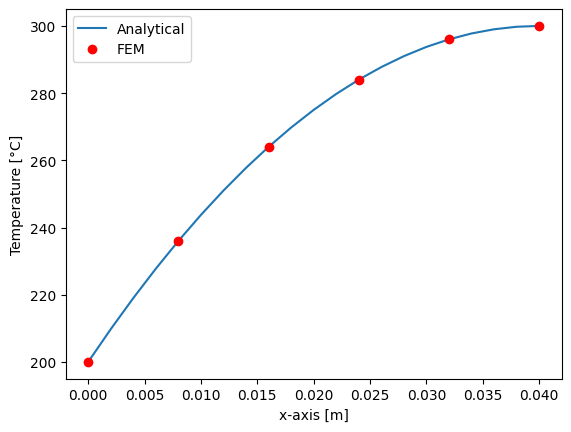

In [9]:
# Analytical solution

h = 0.04
n = 1000
k= 0.2
u0 = 0.2
Tm = 200

x_axis = np.array([n*(L/20) for n in range(20+1)])

T_x = Tm + (n/(2*k))*(u0/h)**2 * (2*h*x_axis-x_axis**2)


plt.plot(x_axis, T_x)
plt.plot(Model1.mesh.getXCoor(), Model1.sol['T'], 'or')

plt.legend(['Analytical', 'FEM'])

plt.xlabel("x-axis [m]")
plt.ylabel("Temperature [°C]")